In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.datasets import KarateClub

## load data

In [3]:
dataset = KarateClub()

In [7]:
print("Number of graphs: ", len(dataset))
print("Number of features: ", dataset.num_features)
print("Number of classes: ",dataset.num_classes)
print("Number of node features: ",dataset.num_node_features) ## each node has how many feature?
print("Number of edge features: ",dataset.num_edge_features)

Number of graphs:  1
Number of features:  34
Number of classes:  4
Number of node features:  34
Number of edge features:  0


In [9]:
data = dataset[0] #  first graph 
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


## Undirected vs directed graph

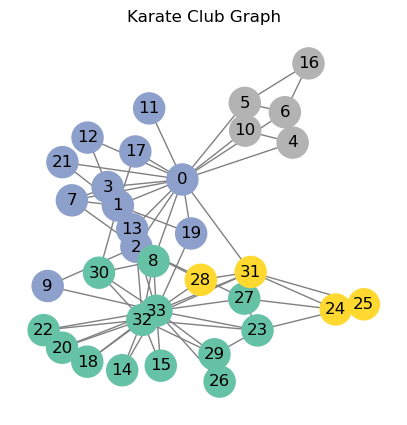

In [19]:
# Convert to networkx
G = to_networkx(data, to_undirected=True) ## undirected 

# Node colors from labels
node_color = data.y.numpy()

# Draw
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_color=node_color,
    cmap=plt.cm.Set2,
    with_labels=True,
    node_size=500,
    edge_color="gray"
)

plt.title("Karate Club Graph")
plt.axis("off")
plt.show()

In [27]:
karate_undirected_graph = to_networkx(data, to_undirected=True)
print(karate_undirected_graph.nodes)
print(karate_undirected_graph.number_of_edges())
print(karate_undirected_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
78
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)]


### directed graph

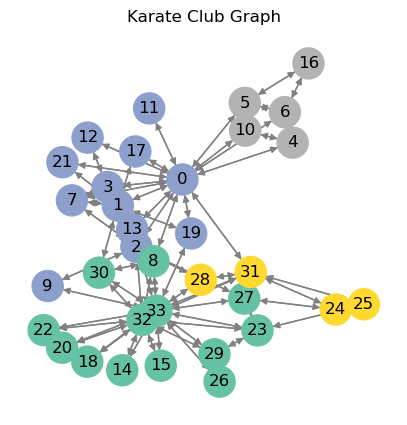

In [20]:
# Convert to networkx
G = to_networkx(data, to_undirected=False) ## directed 

# Node colors from labels
node_color = data.y.numpy()

# Draw
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_color=node_color,
    cmap=plt.cm.Set2,
    with_labels=True,
    node_size=500,
    edge_color="gray"
)

plt.title("Karate Club Graph")
plt.axis("off")
plt.show()

In [26]:
karate_directed_graph = to_networkx(data, to_undirected=False)
print(karate_directed_graph.nodes)
print(karate_directed_graph.number_of_edges())
print(karate_directed_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
156
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 0), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 0), (2, 1), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 0), (3, 1), (3, 2), (3, 7), (3, 12), (3, 13), (4, 0), (4, 6), (4, 10), (5, 0), (5, 6), (5, 10), (5, 16), (6, 0), (6, 4), (6, 5), (6, 16), (7, 0), (7, 1), (7, 2), (7, 3), (8, 0), (8, 2), (8, 30), (8, 32), (8, 33), (9, 2), (9, 33), (10, 0), (10, 4), (10, 5), (11, 0), (12, 0), (12, 3), (13, 0), (13, 1), (13, 2), (13, 3), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (16, 5), (16, 6), (17, 0), (17, 1), (18, 32), (18, 33), (19, 0), (19, 1), (19, 33), (20, 32), (20, 33), (21, 0), (21, 1), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 

#### Directed and Undirected Graph handling in PyG

PyG does not distinguish between directed and undirected graphs, and treats undirected graphs as a special case of directed graphs in which reverse edges exist for every entry in ``edge_index``

## Data exploration

In [29]:
data.stores

[{'x': tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]), 'edge_index': tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
           3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
           7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
          13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
          21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
          27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
          31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
          33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
    

In [30]:
### targes
data.y

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])

In [35]:
print(data.train_mask)
print("number of data for traning:",data.train_mask.sum())

tensor([ True, False, False, False,  True, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])
number of data for traning: tensor(4)


Above only 4 nodes have mask value set as True, it means only 4 out of 34 nodes have community or class assignment, rest of the 30 nodes needs community assignment.

Train Mask -> In total, we are only aware of the ground-truth labels of 4 nodes (one for each community), and the task is to infer the community assignment for the remaining nodes.

#NOTE:

If the graph holds the additional attributes i.e. val_mask and test_mask, which denotes which nodes should be used for validation and testing.

### Model Traning